Shape del dataset: (200000, 25)

Primeras 5 filas:

Tipos de datos:

Estadísticas básicas:

Datos faltantes por columna:
Series([], dtype: int64)

Distribución de decision:
decision
0    153932
1     46068
Name: count, dtype: int64
Porcentajes: decision
0    0.76966
1    0.23034
Name: proportion, dtype: float64


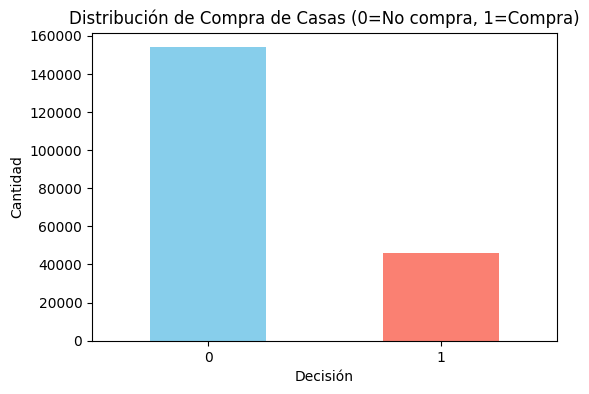

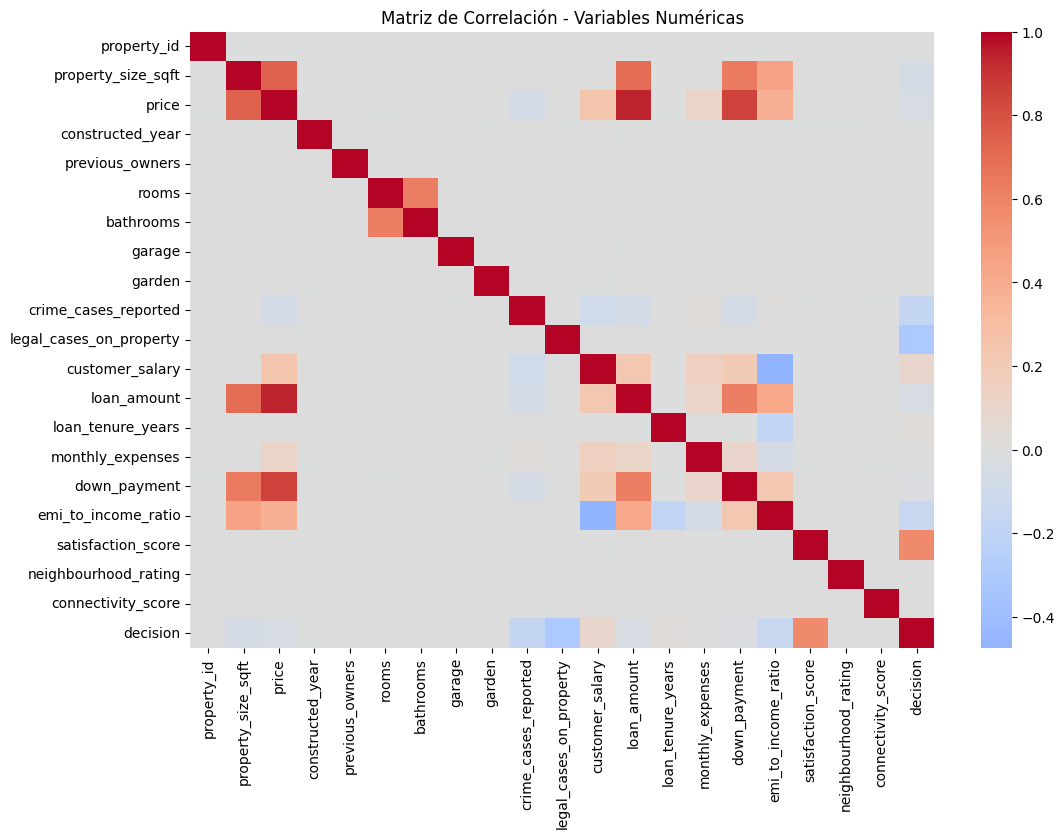


Correlaciones con la variable objetivo:
decision                   1.000000
satisfaction_score         0.572783
customer_salary            0.091546
loan_tenure_years          0.022259
neighbourhood_rating       0.003469
monthly_expenses           0.003010
previous_owners            0.001737
garage                     0.001305
connectivity_score         0.000302
bathrooms                 -0.000400
rooms                     -0.000570
garden                    -0.001019
property_id               -0.001505
constructed_year          -0.003116
down_payment              -0.018453
price                     -0.039607
loan_amount               -0.047227
property_size_sqft        -0.057232
emi_to_income_ratio       -0.156033
crime_cases_reported      -0.166080
legal_cases_on_property   -0.314936
Name: decision, dtype: float64

Columnas categóricas (4):
['country', 'city', 'property_type', 'furnishing_status']

Columnas numéricas (21):
['property_id', 'property_size_sqft', 'price', 'constructed_y

C:\Users\yoset cruz\AppData\Local\Temp\ipykernel_48616\1732492735.py:62: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [7]:
# EDA - Global House Purchase Dataset
# Análisis exploratorio antes de construir la red neuronal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGAR DATOS
df = pd.read_csv('../data/global_house_purchase_dataset.csv')

# 2. INFORMACIÓN GENERAL
print("Shape del dataset:", df.shape)
print("\nPrimeras 5 filas:")
df.head()

print("\nTipos de datos:")
df.dtypes

print("\nEstadísticas básicas:")
df.describe()

# 3. VERIFICAR DATOS FALTANTES
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nDatos faltantes por columna:")
print(missing)

# 4. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# IMPORTANTE: Cambia 'Decision' por el nombre real de la columna objetivo
target_col = 'decision'  # ← AJUSTAR según el dataset real

print(f"\nDistribución de {target_col}:")
print(df[target_col].value_counts())
print(f"Porcentajes: {df[target_col].value_counts(normalize=True)}")

# Gráfico de barras
plt.figure(figsize=(6,4))
df[target_col].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Compra de Casas (0=No compra, 1=Compra)')
plt.xlabel('Decisión')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

# 5. CORRELACIONES (solo variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

# Correlaciones con la variable objetivo
if target_col in numeric_cols:
    corr_with_target = corr_matrix[target_col].sort_values(ascending=False)
    print("\nCorrelaciones con la variable objetivo:")
    print(corr_with_target)

# 6. ANÁLISIS POR TIPO DE VARIABLE
# Columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns
print(f"\nColumnas categóricas ({len(cat_cols)}):")
print(cat_cols.tolist())

# Columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nColumnas numéricas ({len(num_cols)}):")
print(num_cols.tolist())

# 7. VISUALIZACIÓN DE VARIABLES CLAVE (ejemplo con ingresos y precio)
# Asumiendo que existen columnas como 'Salary', 'Price' - AJUSTAR según dataset real
if 'Salary' in df.columns and 'Price' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribución de ingresos por decisión
    for ax, col in zip(axes, ['Salary', 'Price']):
        for decision in [0, 1]:
            subset = df[df[target_col] == decision]
            ax.hist(subset[col], bins=30, alpha=0.5, label=f'Decisión {decision}')
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

# 8. RESUMEN PARA LA RED NEURONAL
print("\n" + "="*50)
print("CONCLUSIONES PARA LA RED NEURONAL:")
print("="*50)
print(f"1. Número de features: {len(num_cols) - 1} (excluyendo target)")
print(f"2. Dataset balanceado? {abs(df[target_col].value_counts(normalize=True)[0] - 0.5) < 0.15}")
print(f"3. Datos faltantes: {'Sí' if len(missing) > 0 else 'No'}")
print(f"4. Features categóricas: {len(cat_cols)} (requieren encoding)")
print("5. Sugerencia: Aplicar StandardScaler a variables numéricas")

In [4]:
# Ver TODOS los nombres de columnas
print("Columnas del dataset:")
print(df.columns.tolist())
print(f"\nTotal: {len(df.columns)} columnas")

# Buscar columnas que PODRÍAN ser la objetivo (binarias)
print("\nColumnas con solo 2 valores únicos:")
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count == 2:
        print(f"  - {col}: {df[col].unique()} (valores únicos)")

Columnas del dataset:
['property_id', 'country', 'city', 'property_type', 'furnishing_status', 'property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score', 'decision']

Total: 25 columnas

Columnas con solo 2 valores únicos:
  - garage: [1 0] (valores únicos)
  - garden: [1 0] (valores únicos)
  - legal_cases_on_property: [0 1] (valores únicos)
  - decision: [0 1] (valores únicos)


In [5]:
# Ver primeras 3 filas con todas las columnas
print("Primeras 3 filas completas:")
df.head(3).T  # Transpuesto para ver mejor

Primeras 3 filas completas:


,0,1,2
property_id,1,2,3
country,France,South Africa,South Africa
city,Marseille,Cape Town,Johannesburg
property_type,Farmhouse,Apartment,Farmhouse
furnishing_status,Semi-Furnished,Semi-Furnished,Semi-Furnished
property_size_sqft,991,1244,4152
price,412935,224538,745104
constructed_year,1989,1990,2019
previous_owners,6,4,5
rooms,6,8,2


In [6]:
# Información general del dataset
print("Tipos de datos:")
print(df.dtypes.value_counts())

print("\nColumnas numéricas:")
num_cols = df.select_dtypes(include=['number']).columns
print(num_cols.tolist())

print("\nColumnas categóricas (object):")
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols.tolist())

Tipos de datos:
int64      20
str         4
float64     1
Name: count, dtype: int64

Columnas numéricas:
['property_id', 'property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score', 'decision']

Columnas categóricas (object):
['country', 'city', 'property_type', 'furnishing_status']


C:\Users\yoset cruz\AppData\Local\Temp\ipykernel_48616\537276377.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
